In [3]:
import pandas as pd
import numpy as np

In [4]:
ev = pd.read_excel('/content/ev.xlsx')

In [5]:
ev.head(5)

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014,jan,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0
1,2014,jan,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0
2,2014,jan,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0
3,2014,jan,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0
4,2014,jan,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0


In [6]:
ev.tail(5)

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
96840,2023,dec,2023-12-01,Andaman & Nicobar Island,MOTOR CAR,4-Wheelers,4W_Personal,1
96841,2023,dec,2023-12-01,Andaman & Nicobar Island,MOTOR CYCLE/SCOOTER-USED FOR HIRE,2-Wheelers,2W_Shared,5
96842,2023,dec,2023-12-01,Andaman & Nicobar Island,OMNI BUS,Bus,Bus,0
96843,2023,dec,2023-12-01,Andaman & Nicobar Island,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,0
96844,2023,dec,2023-12-01,Andaman & Nicobar Island,THREE WHEELER (PASSENGER),3-Wheelers,3W_Shared,0


In [7]:
ev.isnull().sum()

,0
Year,0
Month_Name,0
Date,0
State,0
Vehicle_Class,0
Vehicle_Category,0
Vehicle_Type,0
EV_Sales_Quantity,0


In [8]:
ev.duplicated().sum()

np.int64(0)

In [9]:
ev.describe()

,Year,Date,EV_Sales_Quantity
count,96845.000000,96845,96845.000000
mean,2018.622768,2019-01-28 11:00:33.641385728,37.108896
min,2014.000000,2014-01-01 00:00:00,0.000000
25%,2016.000000,2016-08-01 00:00:00,0.000000
50%,2019.000000,2019-02-01 00:00:00,0.000000
75%,2021.000000,2021-09-01 00:00:00,0.000000
max,2024.000000,2024-01-01 00:00:00,20584.000000
std,2.895581,NaN,431.566675


In [10]:
ev.dtypes

,0
Year,int64
Month_Name,object
Date,datetime64[ns]
State,object
Vehicle_Class,object
Vehicle_Category,object
Vehicle_Type,object
EV_Sales_Quantity,int64


In [11]:
ev["Year"] = ev["Year"].astype(int)
ev["Year"]

,Year
0,2014
1,2014
2,2014
3,2014
4,2014
...,...
96840,2023
96841,2023
96842,2023
96843,2023


In [12]:
ev["Month_Name"] = ev["Month_Name"].str.capitalize()
ev["Month_Name"]

,Month_Name
0,Jan
1,Jan
2,Jan
3,Jan
4,Jan
...,...
96840,Dec
96841,Dec
96842,Dec
96843,Dec


In [13]:
ev["Date"] = pd.to_datetime(ev["Date"])
ev["Quarter"] = ev["Date"].dt.quarter
ev["Quarter"]

,Quarter
0,1
1,1
2,1
3,1
4,1
...,...
96840,4
96841,4
96842,4
96843,4


In [14]:
ev['Date'] = pd.to_datetime(ev['Date'], errors='coerce')

# Check result
print(ev['Date'].head())

0   2014-01-01
1   2014-01-01
2   2014-01-01
3   2014-01-01
4   2014-01-01
Name: Date, dtype: datetime64[ns]


In [15]:
ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Year               96845 non-null  int64         
 1   Month_Name         96845 non-null  object        
 2   Date               96845 non-null  datetime64[ns]
 3   State              96845 non-null  object        
 4   Vehicle_Class      96845 non-null  object        
 5   Vehicle_Category   96845 non-null  object        
 6   Vehicle_Type       96845 non-null  object        
 7   EV_Sales_Quantity  96845 non-null  int64         
 8   Quarter            96845 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(2), object(5)
memory usage: 6.3+ MB


In [16]:
ev.head(5)

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Quarter
0,2014,Jan,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0,1
1,2014,Jan,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0,1
2,2014,Jan,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0,1
3,2014,Jan,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0,1
4,2014,Jan,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0,1


## Bivariant Analysis

In [17]:
# YEAR VS EV SALES

ev.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

,Year,EV_Sales_Quantity
0,2014,2392
1,2015,7805
2,2016,49855
3,2017,87420
4,2018,130254
5,2019,166819
6,2020,124684
7,2021,331498
8,2022,1024723
9,2023,1525179


In [18]:
# STATE VS EV SALES

ev.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).reset_index()

,State,EV_Sales_Quantity
0,Uttar Pradesh,732074
1,Maharashtra,401535
2,Karnataka,315498
3,Delhi,268538
4,Rajasthan,228573
5,Bihar,213465
6,Tamil Nadu,206902
7,Gujarat,176713
8,Assam,151917
9,Kerala,133246


In [19]:
# Vehicle_Class vs EV sales

ev.groupby('Vehicle_Class')['EV_Sales_Quantity'].sum()

,EV_Sales_Quantity
Vehicle_Class,
ADAPTED VEHICLE,175
AGRICULTURAL TRACTOR,121
AMBULANCE,3
ANIMAL AMBULANCE,0
ARMOURED/SPECIALISED VEHICLE,0
...,...
TREE TRIMMING VEHICLE,0
VEHICLE FITTED WITH COMPRESSOR,0
VEHICLE FITTED WITH GENERATOR,0


In [20]:
# VEHICLE CATEGORY , VEHICLE TYPE VS EV SALES

ev.groupby(['Vehicle_Category','Vehicle_Type'])['EV_Sales_Quantity'].sum()

Vehicle_Category  Vehicle_Type      
2-Wheelers        2W_Personal           1796340
                  2W_Shared               11765
3-Wheelers        3W_Goods                44974
                  3W_Goods_LowSpeed       90656
                  3W_Personal               421
                  3W_Shared               76132
                  3W_Shared_LowSpeed    1408127
4-Wheelers        4W_Personal            130676
                  4W_Shared               19099
Bus               Bus                      7009
                  Institution Bus             0
Others            Others                   8612
Name: EV_Sales_Quantity, dtype: int64

In [21]:
# Quarter vs ev sales

ev.groupby('Quarter')['EV_Sales_Quantity'].sum()

,EV_Sales_Quantity
Quarter,
1,889330
2,724695
3,877928
4,1101858


In [22]:
month_order = ["Jan","Feb","Mar" , "Apr", "May", "Jun", "Jul", "Aug" ,"Sep", "Oct" , "Nov" , "Dec"]
ev["Month_Name"] = pd.Categorical(ev["Month_Name"], categories = month_order, ordered = True)

In [23]:
# month name vs ev sales

ev.groupby('Month_Name')['Vehicle_Category'].sum().reset_index()

/tmp/ipykernel_890/1355618089.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ev.groupby('Month_Name')['Vehicle_Category'].sum().reset_index()


,Month_Name,Vehicle_Category
0,Jan,OthersOthersOthersOthersBusOthersOthersBusOthe...
1,Feb,OthersOthersOthersBusOthersOthersOthersBusOthe...
2,Mar,OthersOthersOthersBusOthersOthersBusOthersOthe...
3,Apr,OthersOthersOthersOthersBusOthersOthersOthersB...
4,May,BusOthers2-Wheelers2-Wheelers4-Wheelers4-Wheel...
5,Jun,OthersOthersOthersBusOthersOthersOthersBusOthe...
6,Jul,OthersOthersOthersOthersBusOthersOthersBusOthe...
7,Aug,OthersOthersOthersOthersBusOthersOthersBusOthe...
8,Sep,OthersOthersOthersBusOthersOthersBusOthersOthe...
9,Oct,OthersOthersOthersOthersBusOthersOthersBusOthe...


In [24]:
ev.groupby('Month_Name')['EV_Sales_Quantity'].sum().sort_values(ascending=False).reset_index()

/tmp/ipykernel_890/2702144855.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ev.groupby('Month_Name')['EV_Sales_Quantity'].sum().sort_values(ascending=False).reset_index()


,Month_Name,EV_Sales_Quantity
0,Nov,382217
1,Dec,364558
2,Jan,360703
3,Oct,355083
4,Sep,313433
5,Mar,299888
6,Aug,294022
7,Jul,270473
8,May,262747
9,Apr,232194


In [25]:
Mvv = ev.groupby(["Month_Name","Vehicle_Category","Vehicle_Type"], observed=True).agg({"EV_Sales_Quantity" : "sum"}).head(30)
Mvv[Mvv["EV_Sales_Quantity"] > 0]

EV_Sales_Quantity
Month_Name Vehicle_Category Vehicle_Type                         
Jan        2-Wheelers       2W_Personal                    185693
                            2W_Shared                        2099
           3-Wheelers       3W_Goods                         4032
                            3W_Goods_LowSpeed                9023
                            3W_Personal                        48
                            3W_Shared                        9445
                            3W_Shared_LowSpeed             134366
           4-Wheelers       4W_Personal                     11923
                            4W_Shared                        2416
           Bus              Bus                               828
           Others           Others                            830
Feb        2-Wheelers       2W_Personal                    113260
                            2W_Shared                        1182
           3-Wheelers       3W_Goods                         2382
                            3W_Goods_LowSpeed                7485
                            3W_Personal                        27
                            3W_Shared                        2768
                            3W_Shared_LowSpeed              91812
           4-Wheelers       4W_Personal                      7789
                            4W_Shared                        1101
           Bus              Bus                               512
           Others           Others                            421
Mar        2-Wheelers       2W_Personal                    161671
                            2W_Shared                         769
           3-Wheelers       3W_Goods                         3963
                            3W_Goods_LowSpeed                9203
                            3W_Personal                        57
                            3W_Shared                        3772

In [26]:
State_Mh = ev[ev["State"]=="Maharashtra"]
State_Mh

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Quarter
348,2014,Jan,2014-01-01,Maharashtra,ADAPTED VEHICLE,Others,Others,0,1
349,2014,Jan,2014-01-01,Maharashtra,AGRICULTURAL TRACTOR,Others,Others,0,1
350,2014,Jan,2014-01-01,Maharashtra,AMBULANCE,Others,Others,0,1
351,2014,Jan,2014-01-01,Maharashtra,ARTICULATED VEHICLE,Others,Others,0,1
352,2014,Jan,2014-01-01,Maharashtra,BUS,Bus,Bus,0,1
...,...,...,...,...,...,...,...,...,...
96294,2023,Dec,2023-12-01,Maharashtra,TOW TRUCK,Others,Others,0,4
96295,2023,Dec,2023-12-01,Maharashtra,TRACTOR (COMMERCIAL),Others,Others,0,4
96296,2023,Dec,2023-12-01,Maharashtra,TRAILER (AGRICULTURAL),Others,Others,0,4
96297,2023,Dec,2023-12-01,Maharashtra,TRAILER (COMMERCIAL),Others,Others,0,4


In [27]:
# year vs EV sales Quantity for state  = maharashtra

State_Mh.groupby('Year')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

,EV_Sales_Quantity
Year,
2023,193935
2022,136036
2021,29907
2024,18745
2019,7319
2020,7137
2018,4640
2015,1015
2016,951


In [28]:
# Month_Name vs EV sales Quantity for state  = maharashtra

State_Mh.groupby('Month_Name')['EV_Sales_Quantity'].sum().sort_index()

/tmp/ipykernel_890/1982395513.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  State_Mh.groupby('Month_Name')['EV_Sales_Quantity'].sum().sort_index()


,EV_Sales_Quantity
Month_Name,
Jan,43074
Feb,25430
Mar,36110
Apr,24774
May,34581
Jun,22744
Jul,26045
Aug,30113
Sep,30794


In [29]:
# Quarter vs EV sales Quantity for state  = maharashtra

State_Mh.groupby('Quarter')['EV_Sales_Quantity'].sum()

,EV_Sales_Quantity
Quarter,
1,104614
2,82099
3,86952
4,127870


In [30]:
# Vehicle_Class vs EV sales Quantity for state  = maharashtra

State_Mh.groupby('Vehicle_Class')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(25)

,EV_Sales_Quantity
Vehicle_Class,
M-CYCLE/SCOOTER,330422
MOTOR CAR,29253
E-RICKSHAW(P),13359
MOPED,11670
E-RICKSHAW WITH CART (G),4678
THREE WHEELER (GOODS),3941
MOTOR CAB,3063
THREE WHEELER (PASSENGER),2651
BUS,1712


In [31]:
# Vehicle_Category ,vehicle Type vs EV sales Quantity for state  = maharashtra

State_Mh.groupby(['Vehicle_Category','Vehicle_Type'])['EV_Sales_Quantity'].sum()

Vehicle_Category  Vehicle_Type      
2-Wheelers        2W_Personal           342231
                  2W_Shared                  5
3-Wheelers        3W_Goods                3941
                  3W_Goods_LowSpeed       4678
                  3W_Personal               38
                  3W_Shared               2651
                  3W_Shared_LowSpeed     13359
4-Wheelers        4W_Personal            29253
                  4W_Shared               3064
Bus               Bus                     1712
                  Institution Bus            0
Others            Others                   603
Name: EV_Sales_Quantity, dtype: int64

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

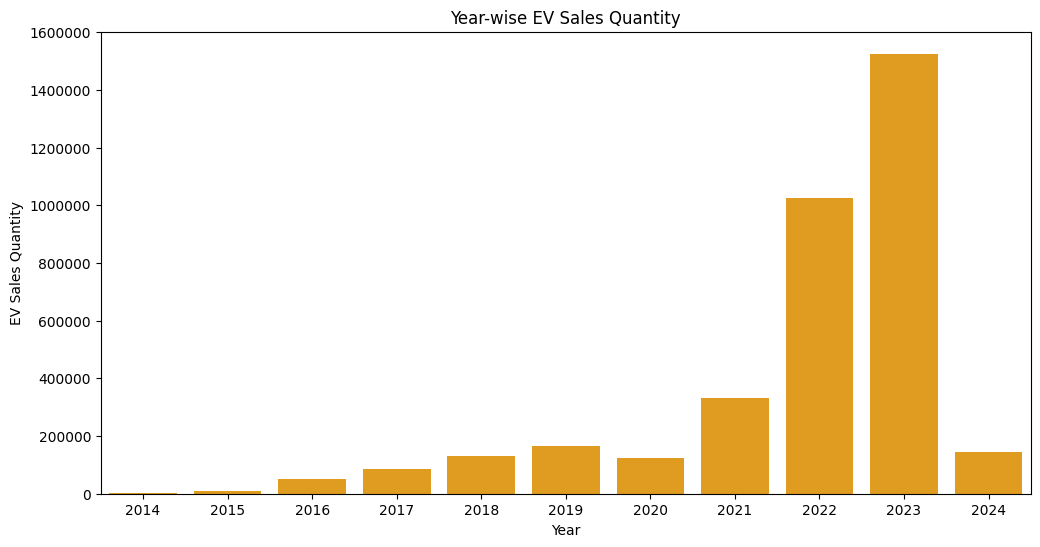

In [33]:
# Year wise EV sales Quantity

year_sales = ev.groupby("Year")["EV_Sales_Quantity"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=year_sales, x="Year", y="EV_Sales_Quantity", color="orange")

plt.title("Year-wise EV Sales Quantity")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [34]:
plt.figure(figsize=(12,6))



<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

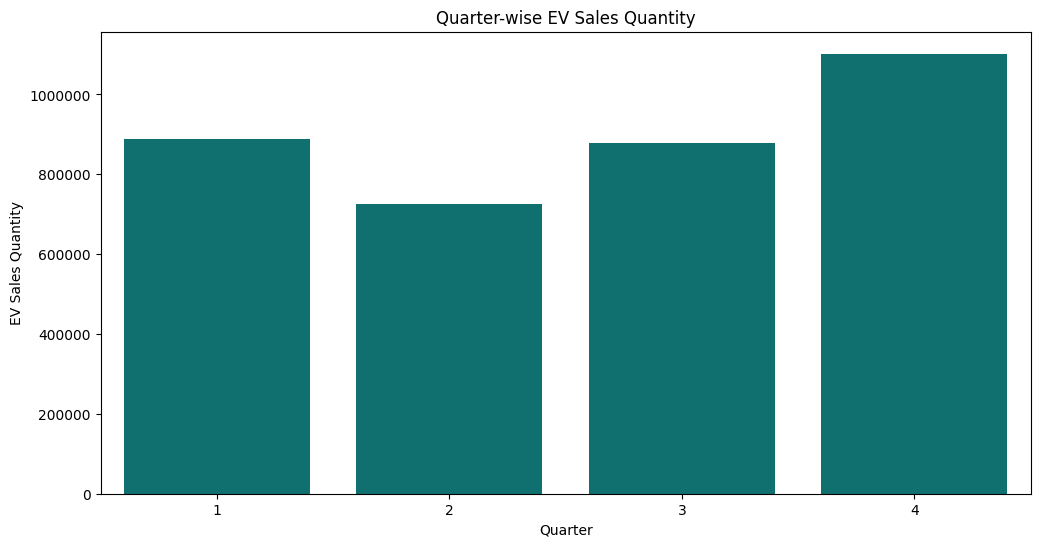

In [35]:
# Quarter wise EV sales Quantity

quarter_sales = ev.groupby("Quarter")["EV_Sales_Quantity"].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=quarter_sales, x="Quarter", y="EV_Sales_Quantity", color="teal")

plt.title("Quarter-wise EV Sales Quantity")
plt.xlabel("Quarter")
plt.ylabel("EV Sales Quantity")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

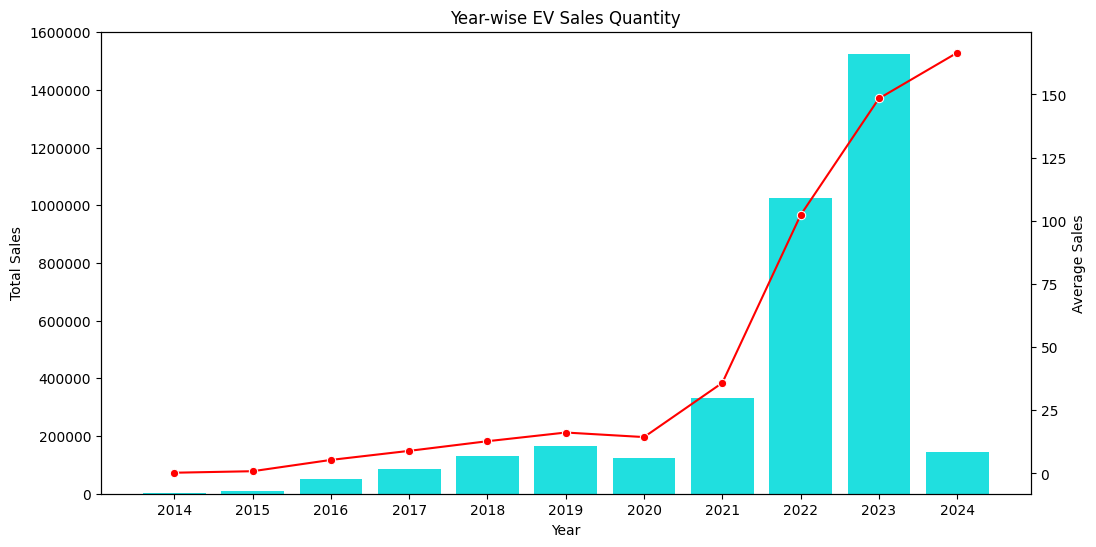

In [36]:
# year wise EV sales quantity

# Aggregate once (better practice)
year_sales = ev.groupby("Year")["EV_Sales_Quantity"].agg(["sum", "mean"]).reset_index()
year_sales = year_sales.sort_values("Year")

# Rename columns for clarity
year_sales.rename(columns={"sum": "Total_Sales", "mean": "Average_Sales"}, inplace=True)

# Convert Year to string for better plotting
year_sales["Year"] = year_sales["Year"].astype(str)

# Create plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot (Total Sales)
sns.barplot(data=year_sales, x="Year", y="Total_Sales", color="cyan", ax=ax1)
ax1.set_ylabel("Total Sales")
ax1.set_xlabel("Year")
ax1.ticklabel_format(style="plain", axis="y")

# Line plot (Average Sales)
ax2 = ax1.twinx()
sns.lineplot(data=year_sales, x="Year", y="Average_Sales", ax=ax2, color="red", marker="o")
ax2.set_ylabel("Average Sales")

plt.title("Year-wise EV Sales Quantity")
plt.show()

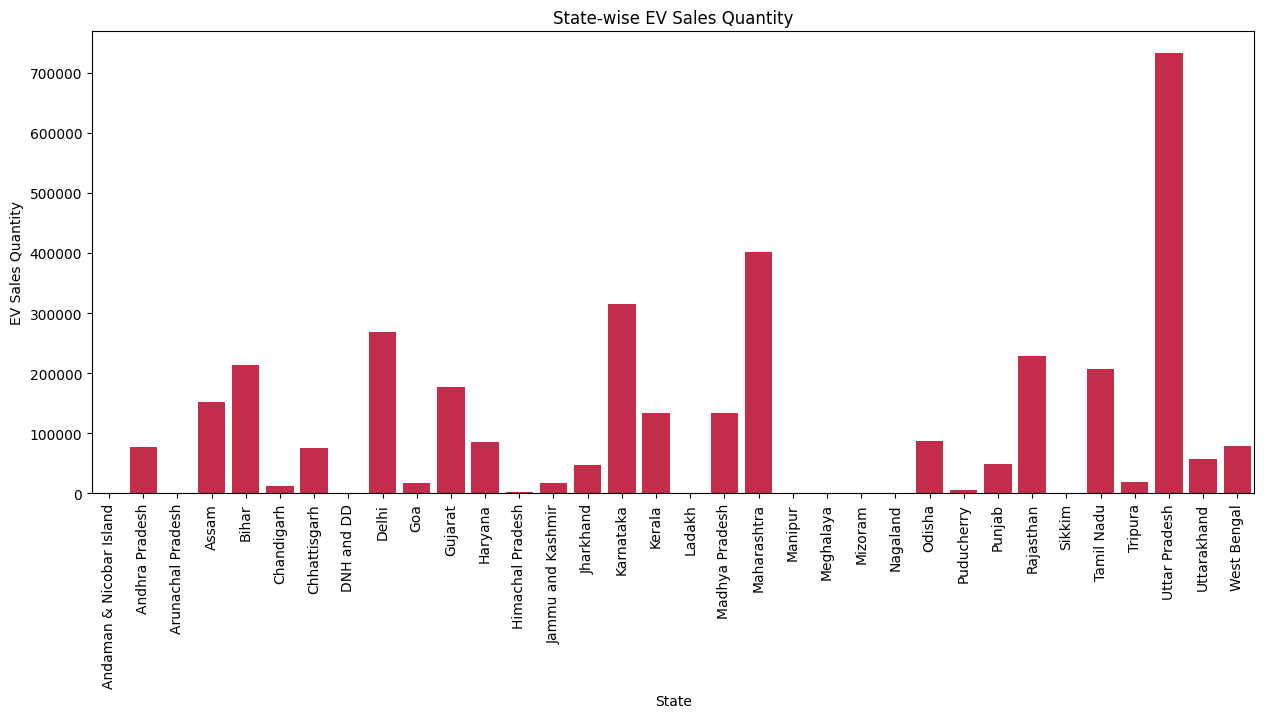

In [37]:

# Group data
state_sales = ev.groupby("State")["EV_Sales_Quantity"].sum().reset_index()

# Plot
plt.figure(figsize=(15,6))
sns.barplot(data=state_sales, x="State", y="EV_Sales_Quantity", color="crimson")

plt.title("State-wise EV Sales Quantity")
plt.xlabel("State")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=90)

plt.show()

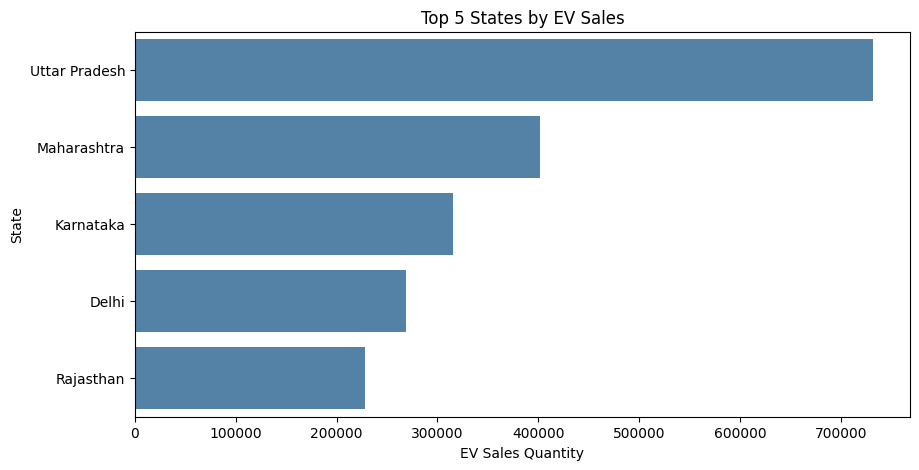

In [38]:
#  Top 5 states by EV sales

top_states = (
    ev.groupby("State")["EV_Sales_Quantity"]
    .sum()
    .reset_index()
    .sort_values("EV_Sales_Quantity", ascending=False)
    .head(5)
)

# Plot (horizontal bar chart - better for readability)
plt.figure(figsize=(10,5))
sns.barplot(data=top_states, y="State", x="EV_Sales_Quantity", color="steelblue")

plt.title("Top 5 States by EV Sales")
plt.xlabel("EV Sales Quantity")
plt.ylabel("State")

plt.show()

/tmp/ipykernel_890/333287842.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month_sales = ev.groupby("Month_Name")["EV_Sales_Quantity"].sum().reset_index()


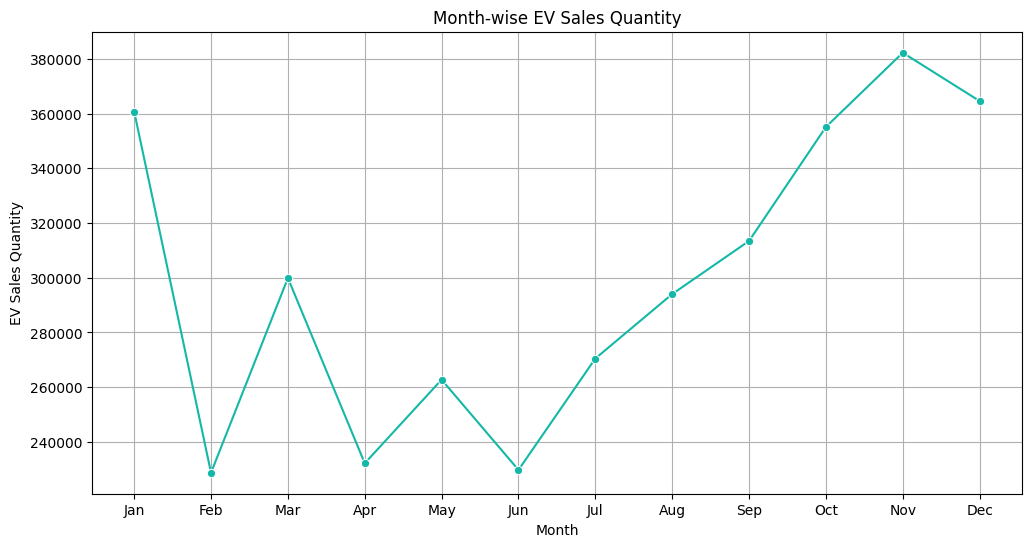

In [39]:
# MOnth wise EV sales quantity

# Group data
month_sales = ev.groupby("Month_Name")["EV_Sales_Quantity"].sum().reset_index()

# Correct month order
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_sales["Month_Name"] = pd.Categorical(month_sales["Month_Name"], categories=month_order, ordered=True)
month_sales = month_sales.sort_values("Month_Name")

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=month_sales, x="Month_Name", y="EV_Sales_Quantity",
             marker="o", color="#14B8A6")  # premium teal color

plt.title("Month-wise EV Sales Quantity")
plt.xlabel("Month")
plt.ylabel("EV Sales Quantity")
plt.grid()

plt.show()

In [41]:
# vehicle class vs EV sales Quantity

vc = ev.groupby("Vehicle_Class")["EV_Sales_Quantity"].sum().reset_index()
vc

,Vehicle_Class,EV_Sales_Quantity
0,ADAPTED VEHICLE,175
1,AGRICULTURAL TRACTOR,121
2,AMBULANCE,3
3,ANIMAL AMBULANCE,0
4,ARMOURED/SPECIALISED VEHICLE,0
...,...,...
68,TREE TRIMMING VEHICLE,0
69,VEHICLE FITTED WITH COMPRESSOR,0
70,VEHICLE FITTED WITH GENERATOR,0
71,VEHICLE FITTED WITH RIG,18


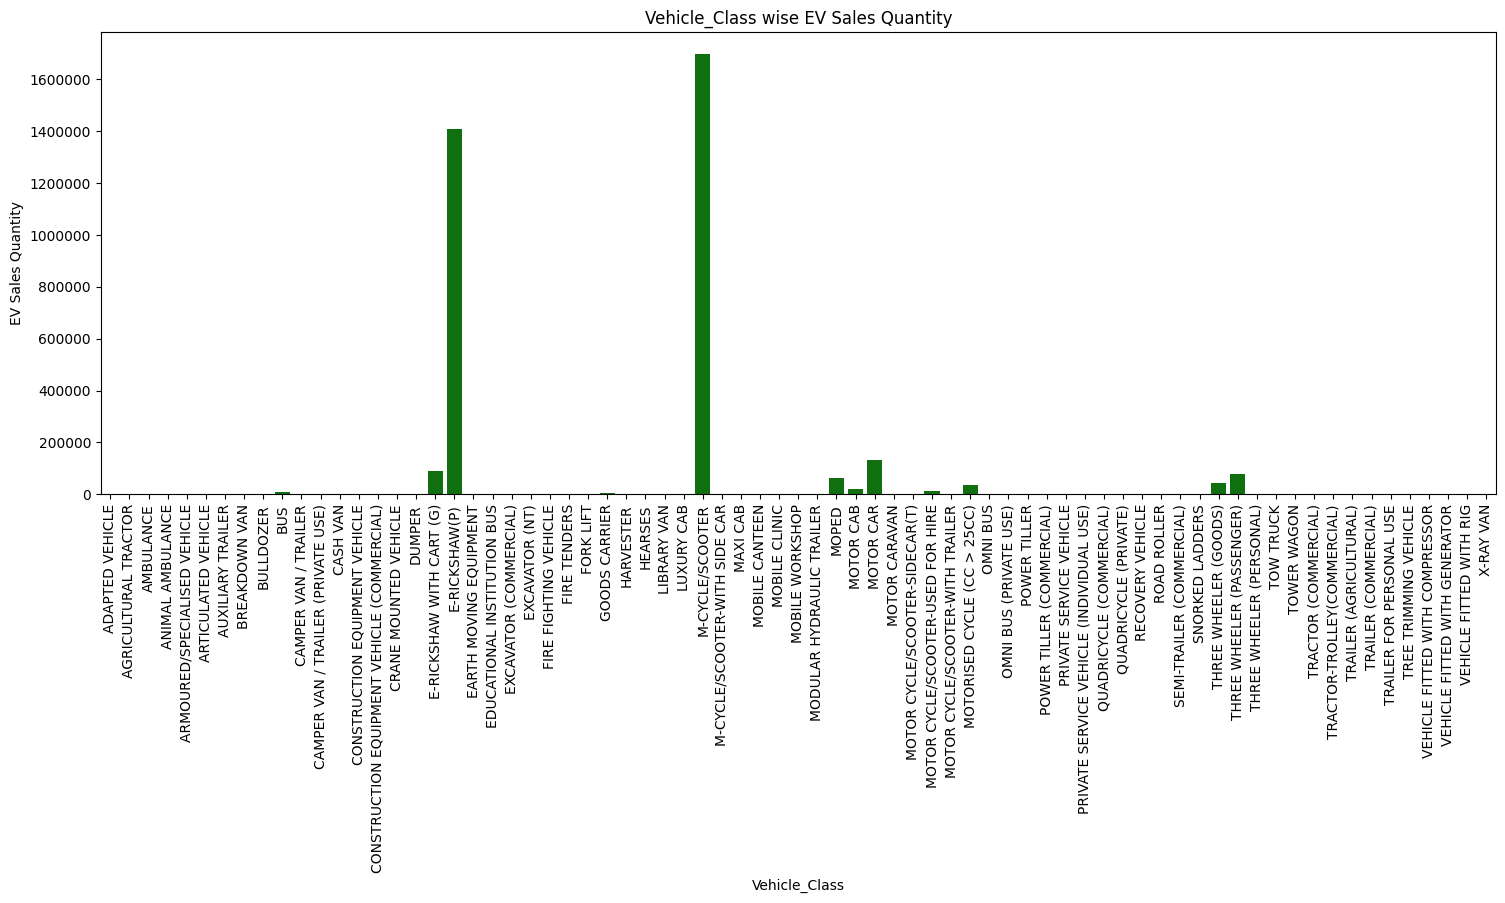

In [42]:
plt.figure(figsize=(18,6))
sns.barplot(data= vc, x="Vehicle_Class", y="EV_Sales_Quantity", color = "green")
plt.title("Vehicle_Class wise EV Sales Quantity")
plt.xlabel("Vehicle_Class")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=90)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

In [63]:
# vehicle type vs EV sales quantity

vt = ev.groupby("Vehicle_Type")["EV_Sales_Quantity"].sum().sort_values(ascending=False).reset_index().head(5)
vt

,Vehicle_Type,EV_Sales_Quantity
0,2W_Personal,1796340
1,3W_Shared_LowSpeed,1408127
2,4W_Personal,130676
3,3W_Goods_LowSpeed,90656
4,3W_Shared,76132


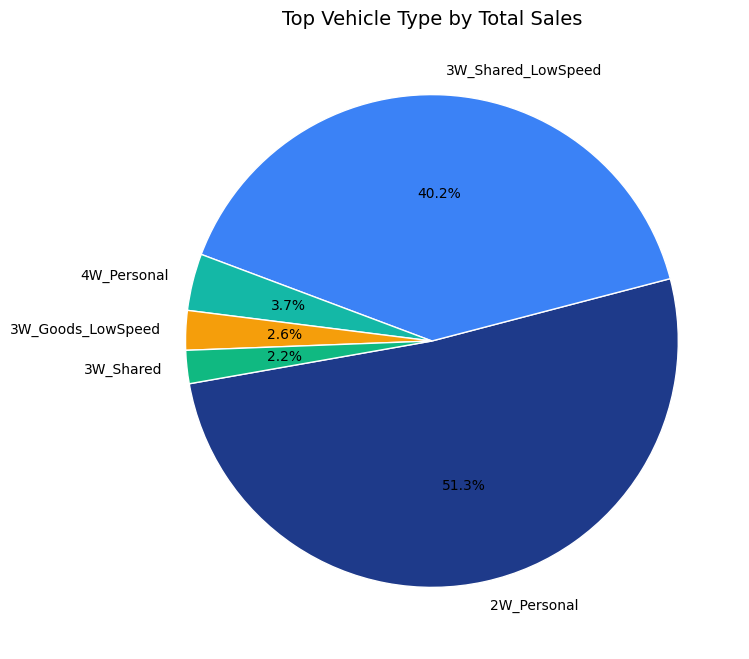

In [64]:
plt.figure(figsize=(10,8))

plt.pie(
    vt["EV_Sales_Quantity"],
    labels=vt["Vehicle_Type"],
    autopct='%1.1f%%',
    startangle=190,
    colors=["#1E3A8A", "#3B82F6", "#14B8A6", "#F59E0B", "#10B981"],  # premium palette
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Top Vehicle Type by Total Sales", fontsize=14)

plt.show()

In [67]:
# vehicle category vs EV sales quantity

vct = ev.groupby("Vehicle_Category")["EV_Sales_Quantity"].sum().sort_values(ascending=False).reset_index()
vct

,Vehicle_Category,EV_Sales_Quantity
0,2-Wheelers,1808105
1,3-Wheelers,1620310
2,4-Wheelers,149775
3,Others,8612
4,Bus,7009


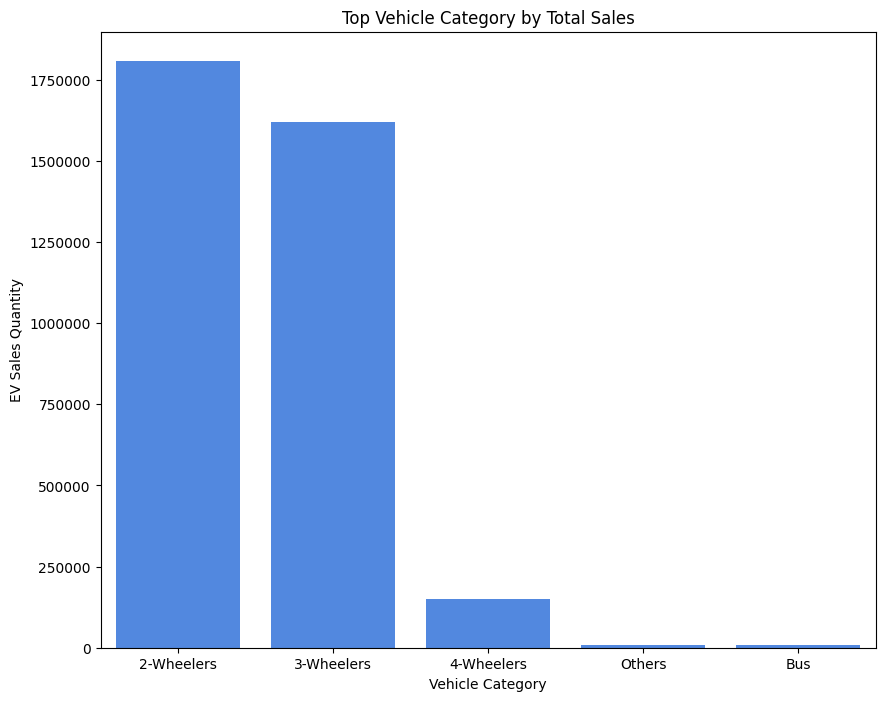

In [70]:


# Sort data (important)
vct = vct.sort_values("EV_Sales_Quantity", ascending=False)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(data=vct, x="Vehicle_Category", y="EV_Sales_Quantity", color="#3B82F6")

plt.title("Top Vehicle Category by Total Sales")
plt.xlabel("Vehicle Category")
plt.ylabel("EV Sales Quantity")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

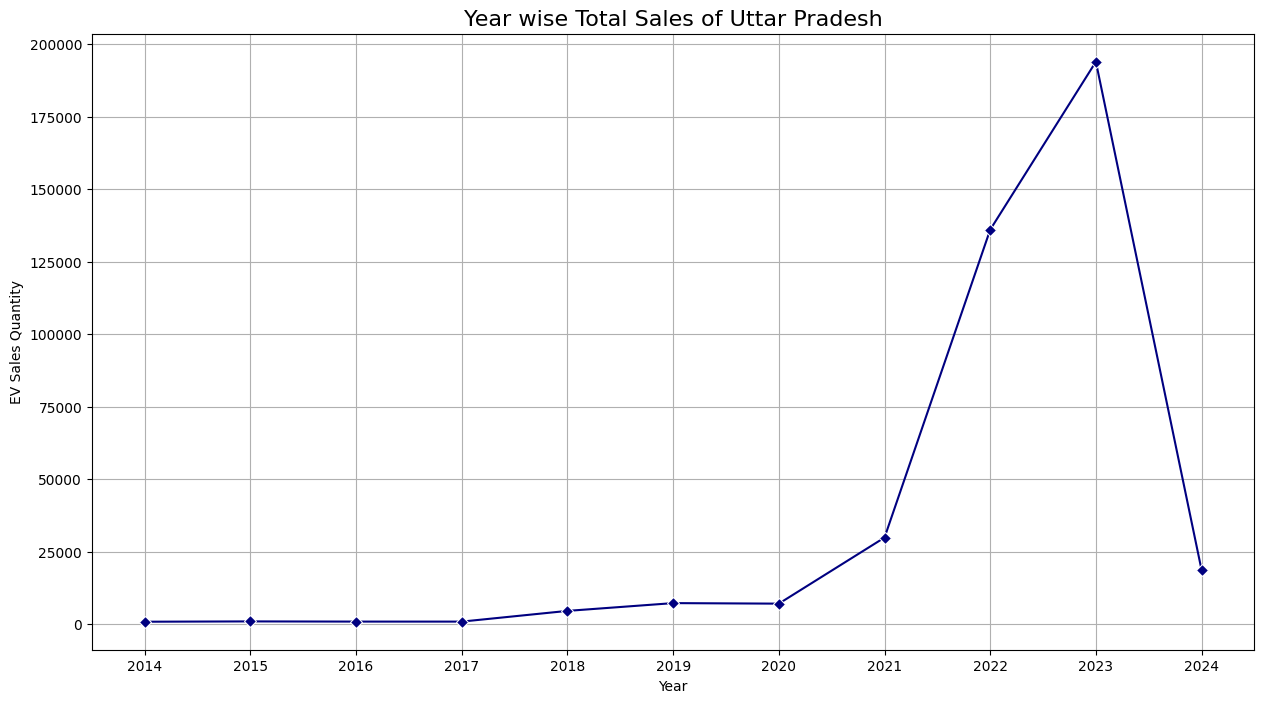

In [78]:
# year vs ev sales quantity by state = maharashtra

mh_y = State_Mh.groupby("Year")["EV_Sales_Quantity"].sum().reset_index()
mh_y['Year']= mh_y['Year'].astype(str)

plt.figure(figsize=(15, 8))

sns.lineplot(data = mh_y, x="Year" , y="EV_Sales_Quantity",color = "navy", marker= "D")

plt.title("Year wise Total Sales of Uttar Pradesh", fontsize = 16)

plt.xlabel("Year")

plt.ylabel("EV Sales Quantity")

plt.ticklabel_format(style="plain", axis="y")
plt.grid()
plt.show()

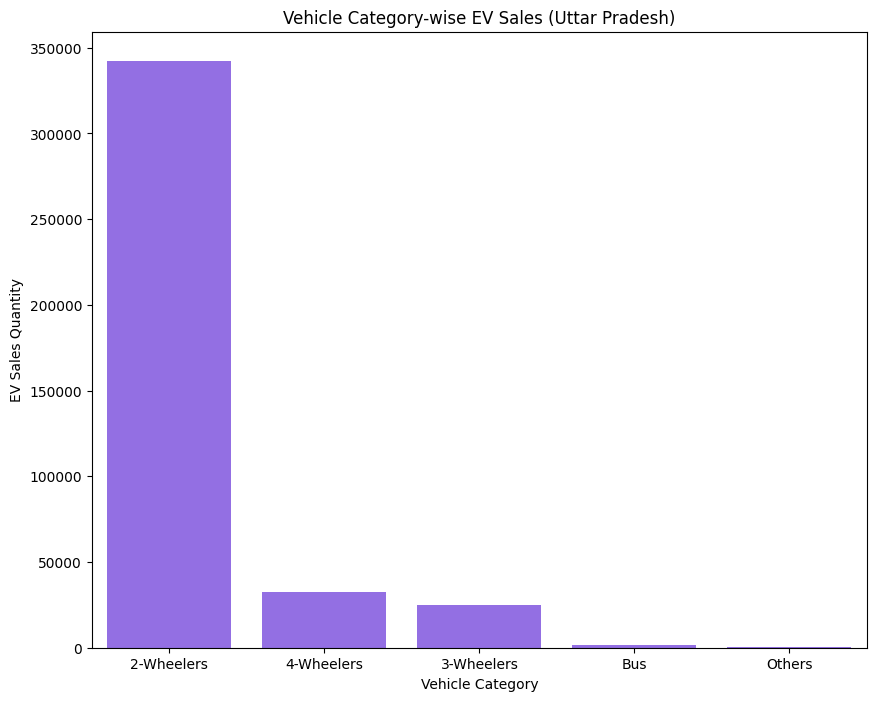

In [80]:
# vehicle category wise EV sales

# Group data
mh_ct = (
    State_Mh.groupby("Vehicle_Category")["EV_Sales_Quantity"]
    .sum()
    .reset_index()
    .sort_values("EV_Sales_Quantity", ascending=False)
)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(data=mh_ct, x="Vehicle_Category", y="EV_Sales_Quantity", color="#8B5CF6")

plt.title("Vehicle Category-wise EV Sales (Uttar Pradesh)")
plt.xlabel("Vehicle Category")
plt.ylabel("EV Sales Quantity")
plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [83]:
Y_S = ev.groupby(["Year" , "State"]).agg({"EV_Sales_Quantity" : "sum"})
Year_wise_Top_State = Y_S.sort_values(["Year", "EV_Sales_Quantity"],ascending=[True, False]).groupby("Year").head(1).reset_index()
Year_wise_Top_State

,Year,State,EV_Sales_Quantity
0,2014,Maharashtra,905
1,2015,Delhi,3565
2,2016,Delhi,21688
3,2017,Uttar Pradesh,40649
4,2018,Uttar Pradesh,53212
5,2019,Uttar Pradesh,55796
6,2020,Uttar Pradesh,31264
7,2021,Uttar Pradesh,66702
8,2022,Uttar Pradesh,162857
9,2023,Uttar Pradesh,277300


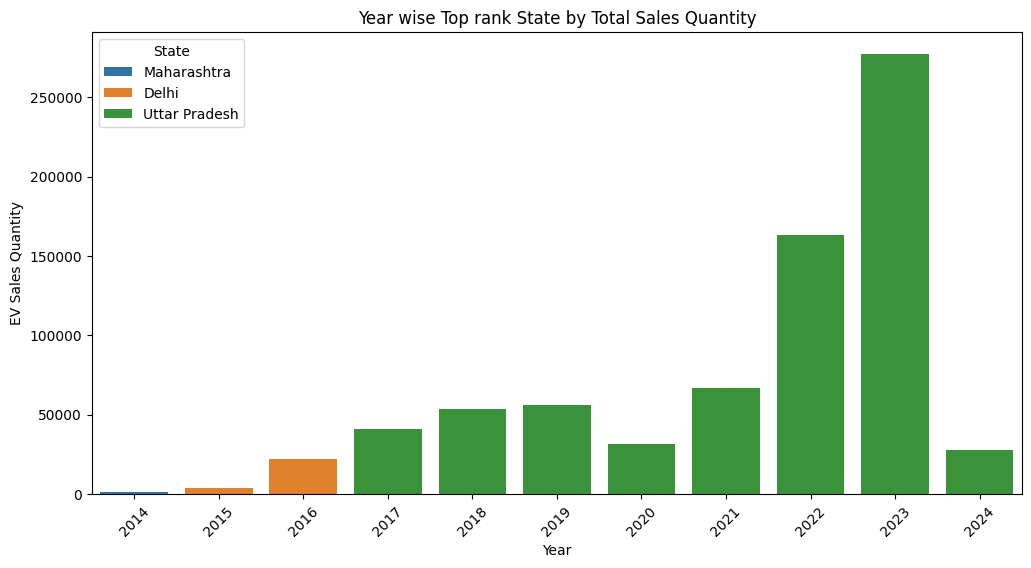

In [84]:
# year wise ev sales quantity by state

plt.figure(figsize=(12,6))
sns.barplot(data=Year_wise_Top_State, x="Year", y="EV_Sales_Quantity", hue="State")
plt.title("Year wise Top rank State by Total Sales Quantity")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=45)
plt.show()

In [88]:
M_S = ev.groupby(["Month_Name","State"])['EV_Sales_Quantity'].sum().reset_index()

M_S = M_S.sort_values(["EV_Sales_Quantity"], ascending =False).groupby("Month_Name",observed=True).head(1).reset_index(drop=True)
M_S = M_S.sort_values("Month_Name").reset_index(drop=True)
M_S


/tmp/ipykernel_890/1646480861.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  M_S = ev.groupby(["Month_Name","State"])['EV_Sales_Quantity'].sum().reset_index()


,Month_Name,State,EV_Sales_Quantity
0,Jan,Uttar Pradesh,75137
1,Feb,Uttar Pradesh,43352
2,Mar,Uttar Pradesh,51864
3,Apr,Uttar Pradesh,44432
4,May,Uttar Pradesh,47105
5,Jun,Uttar Pradesh,52116
6,Jul,Uttar Pradesh,61091
7,Aug,Uttar Pradesh,65581
8,Sep,Uttar Pradesh,68053
9,Oct,Uttar Pradesh,69579


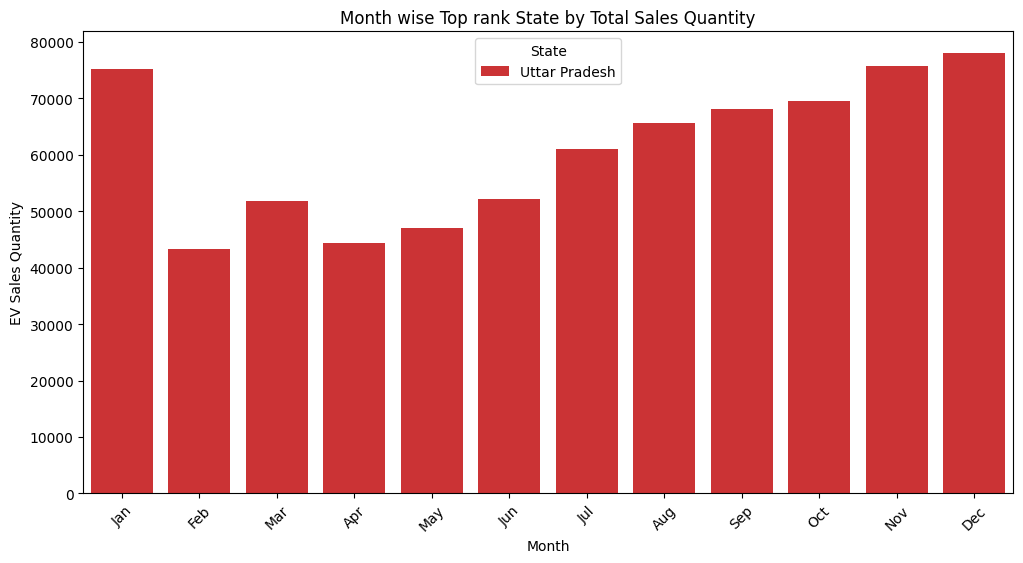

In [92]:
plt.figure(figsize=(12,6))
sns.barplot(data=M_S, x="Month_Name", y="EV_Sales_Quantity", hue="State", palette="Set1")
plt.title("Month wise Top rank State by Total Sales Quantity")
plt.xlabel("Month")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=45)
plt.show()

In [94]:
# year on year changes

Year_on_Year_change = ev.groupby("Year")['EV_Sales_Quantity'].sum().reset_index()
Year_on_Year_change["YOY"] = Year_on_Year_change["EV_Sales_Quantity"].pct_change()*100
Year_on_Year_change = Year_on_Year_change.round(2)
Year_on_Year_change

,Year,EV_Sales_Quantity,YOY
0,2014,2392,NaN
1,2015,7805,226.30
2,2016,49855,538.76
3,2017,87420,75.35
4,2018,130254,49.00
5,2019,166819,28.07
6,2020,124684,-25.26
7,2021,331498,165.87
8,2022,1024723,209.12
9,2023,1525179,48.84


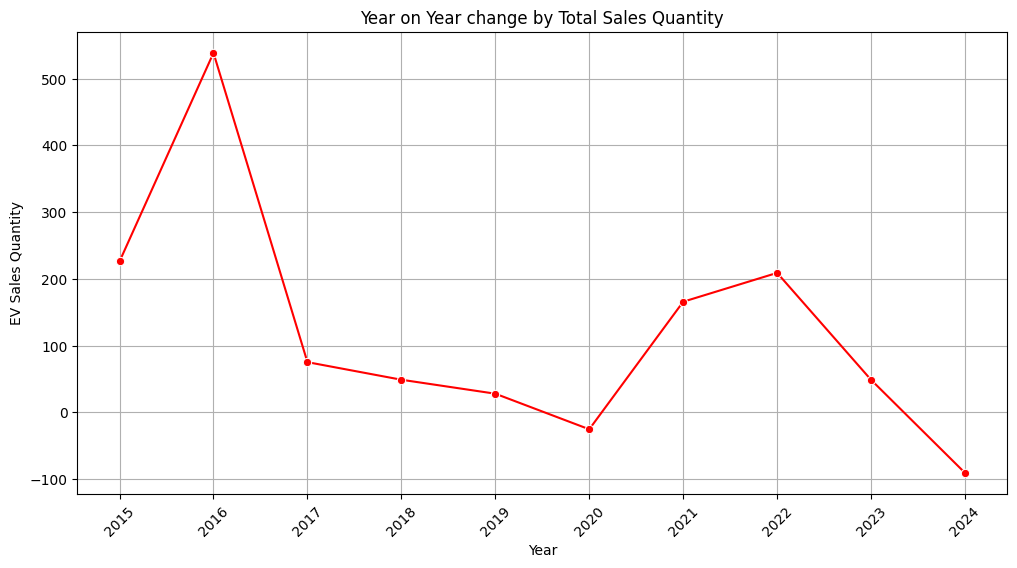

In [95]:
# year on year changes

plt.figure(figsize=(12,6))

Year_on_Year_change["Year"] = Year_on_Year_change["Year"].astype(str)

sns.lineplot(data=Year_on_Year_change, x="Year", y="YOY",marker = "o", color = "red")
plt.title("Year on Year change by Total Sales Quantity")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [96]:
# MOnth on Month changes

Month_on_Month_change = ev.groupby("Month_Name")["EV_Sales_Quantity"].sum().reset_index()
Month_on_Month_change["MOM"] = Month_on_Month_change["EV_Sales_Quantity"].pct_change()*100
Month_on_Month_change = Month_on_Month_change.round(2)
Month_on_Month_change

/tmp/ipykernel_890/308206022.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Month_on_Month_change = ev.groupby("Month_Name")["EV_Sales_Quantity"].sum().reset_index()


,Month_Name,EV_Sales_Quantity,MOM
0,Jan,360703,NaN
1,Feb,228739,-36.59
2,Mar,299888,31.10
3,Apr,232194,-22.57
4,May,262747,13.16
5,Jun,229754,-12.56
6,Jul,270473,17.72
7,Aug,294022,8.71
8,Sep,313433,6.60
9,Oct,355083,13.29


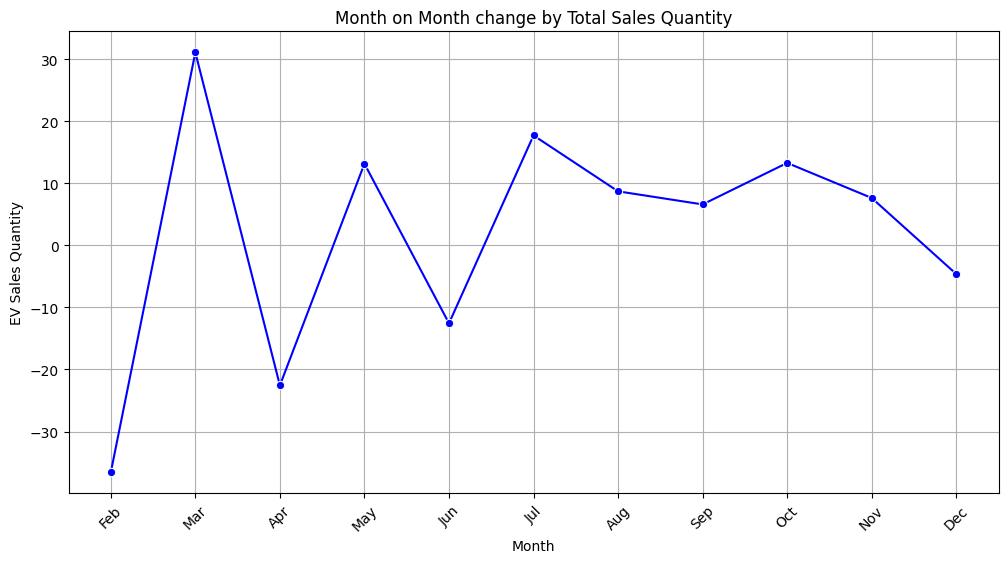

In [97]:
# MOnth on Month changes

plt.figure(figsize=(12,6))


sns.lineplot(data=Month_on_Month_change, x="Month_Name", y="MOM",marker = "o", color = "blue")
plt.title("Month on Month change by Total Sales Quantity")
plt.xlabel("Month")
plt.ylabel("EV Sales Quantity")
plt.xticks(rotation=45)
plt.grid()
plt.show()

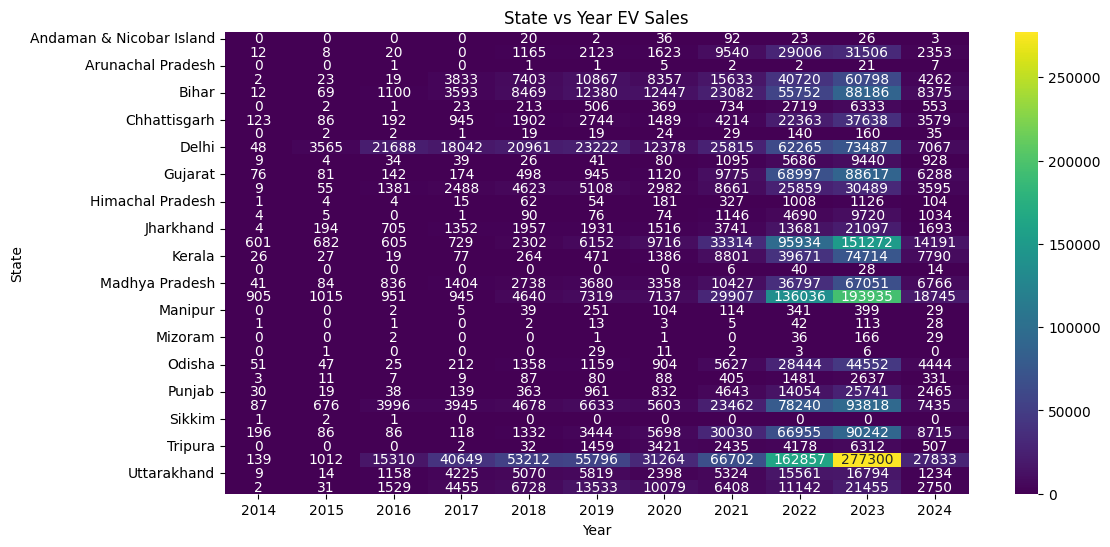

In [103]:
# State vs Year

pivot = ev.pivot_table(
    values="EV_Sales_Quantity",
    index="State",
    columns="Year",
    aggfunc="sum"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis", annot=True, fmt=".0f")

plt.title("State vs Year EV Sales")
plt.show()

# heat map

From the heatmap, I observed that EV sales significantly increased after 2020, with Uttar Pradesh emerging as a dominant market. Additionally, sales are concentrated in a few states, indicating uneven adoption and highlighting opportunities in low-performing regions.

In [101]:
YSS = ev.groupby(["Year","State"])["EV_Sales_Quantity"].sum().reset_index()

pivot1 = YSS.pivot(index = "State", columns = "Year" , values = "EV_Sales_Quantity")

pivot1["Total_Sales"] = pivot1.sum(axis=1)

pivot1 = pivot1.sort_values(by = "Total_Sales", ascending= False)

pivot1= pivot1.drop(columns = "Total_Sales")

pivot1

Year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
State,,,,,,,,,,,
Uttar Pradesh,139,1012,15310,40649,53212,55796,31264,66702,162857,277300,27833
Maharashtra,905,1015,951,945,4640,7319,7137,29907,136036,193935,18745
Karnataka,601,682,605,729,2302,6152,9716,33314,95934,151272,14191
Delhi,48,3565,21688,18042,20961,23222,12378,25815,62265,73487,7067
Rajasthan,87,676,3996,3945,4678,6633,5603,23462,78240,93818,7435
Bihar,12,69,1100,3593,8469,12380,12447,23082,55752,88186,8375
Tamil Nadu,196,86,86,118,1332,3444,5698,30030,66955,90242,8715
Gujarat,76,81,142,174,498,945,1120,9775,68997,88617,6288
Assam,2,23,19,3833,7403,10867,8357,15633,40720,60798,4262


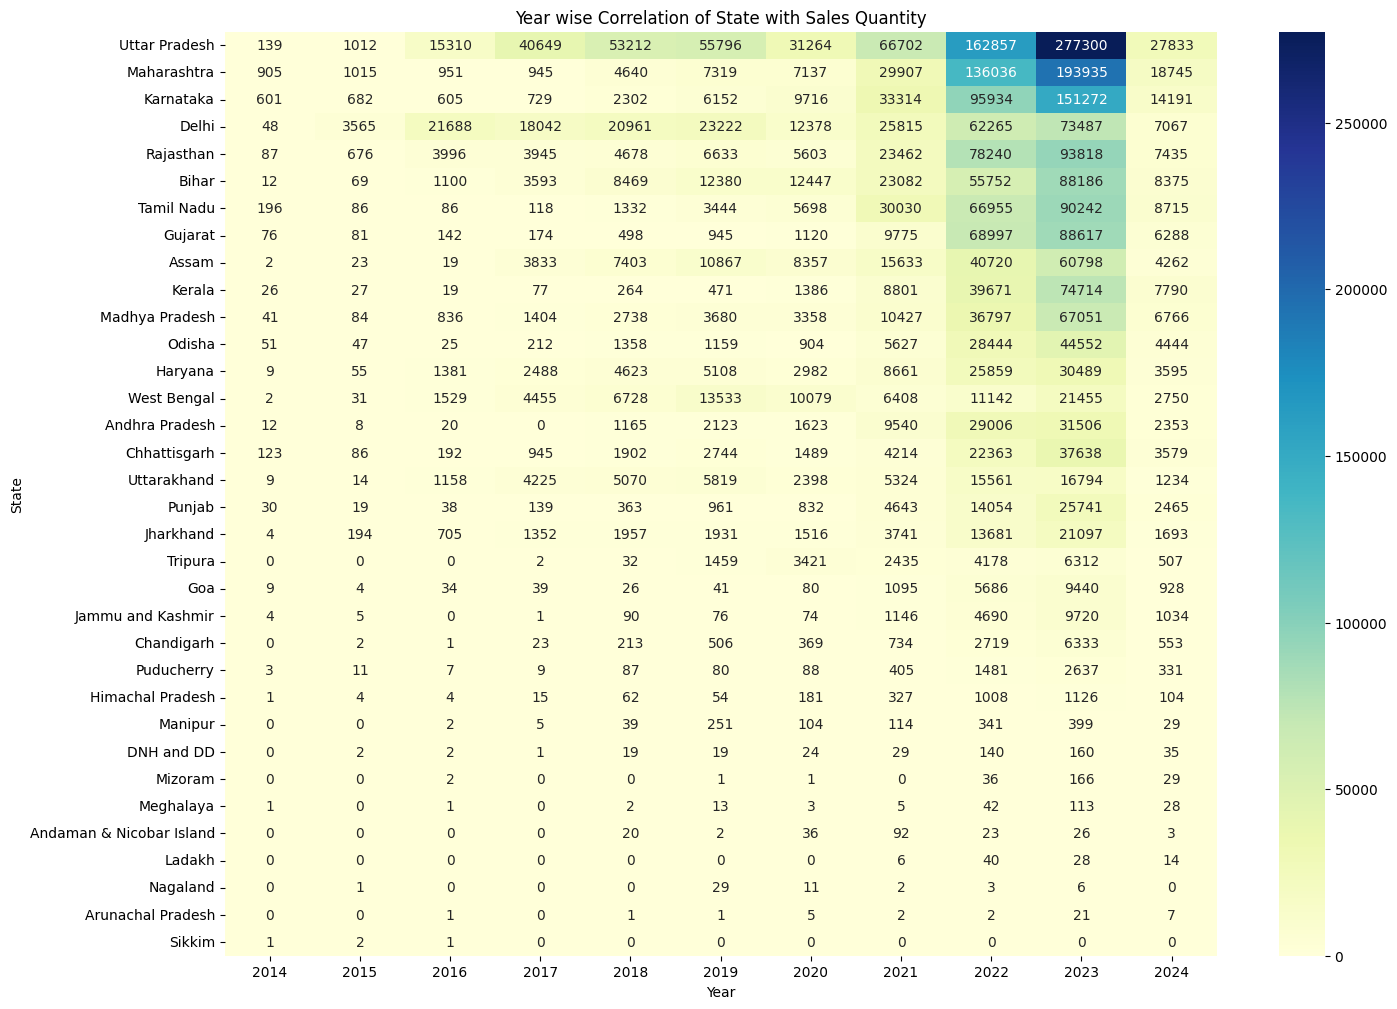

In [99]:
plt.figure(figsize=(16,12))
sns.heatmap(pivot1, cmap="YlGnBu", annot =True, fmt=".0f")
plt.title("Year wise Correlation of State with Sales Quantity")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

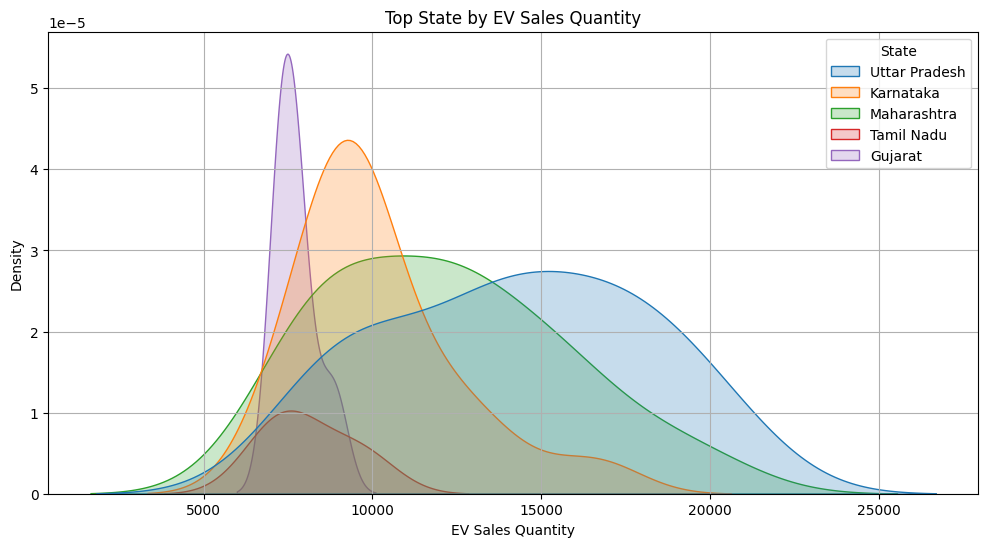

In [102]:
filter1 = ev[ev["EV_Sales_Quantity"] > 7000]
StateEv = filter1.groupby("State")['EV_Sales_Quantity'].sum().reset_index().sort_values(by ="EV_Sales_Quantity", ascending = False )
TopState = StateEv["State"].head(5)
Topfilter = filter1[filter1["State"].isin(TopState)]

plt.figure(figsize=(12, 6))
sns.kdeplot(data= Topfilter, x="EV_Sales_Quantity", hue="State", fill=True)
plt.title("Top State by EV Sales Quantity")
plt.xlabel("EV Sales Quantity")
plt.ylabel("Density")
plt.grid()
plt.show()

## Pairplot

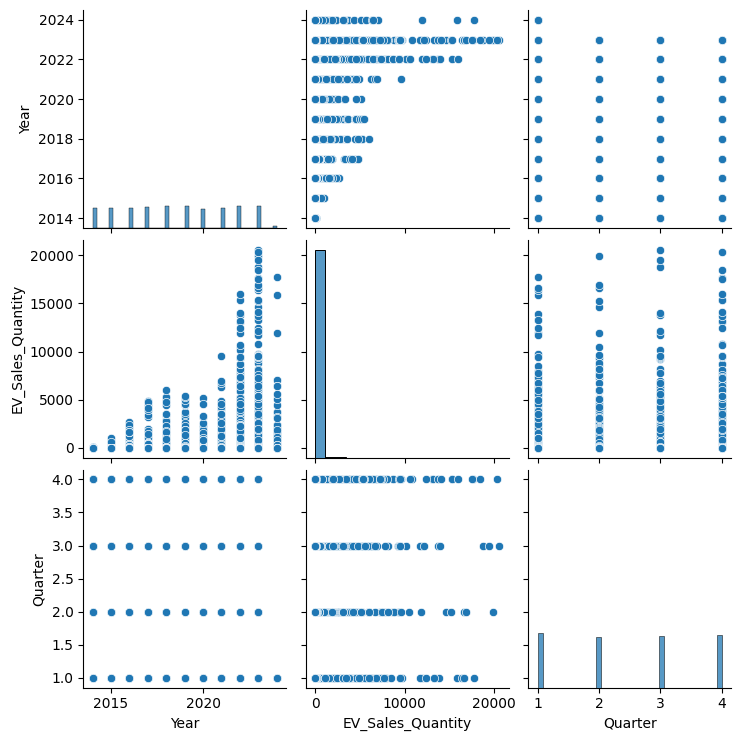

In [107]:
sns.pairplot(ev)